In [9]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/terrablader11/consulting_capstone/refs/heads/main/competitor_data.csv"
data = pd.read_csv(url)
data = data.set_index("Firm", drop=True)

data

,Website,Strategies,Number of Transactions,Number of States/Territories Operating,Years of Experience,"Total Value of Transactions ($, billions)","Average Deal Size ($, millions)",Number of Employees,"Average Transactions per Year ($, billions)","Average Yearly Transactions per Employee ($, millions)","Total Transactions per Employee ($, billions)"
Firm,,,,,,,,,,,
Enhanced Capital,NaN,NaN,1000+,42,25.0,$6.40,NaN,39,$0.26,$6.56,$0.16
Advantage Capital,https://www.advantagecap.com,"small business, affordable housing, renewable ...",NaN,39,34.0,$5.00,NaN,220,$0.15,$0.67,$0.02
Stonehenge Capital,https://stonehengecapital.com/tax-credit-solut...,Private credit and growth equity for growth st...,1000+,35,27.0,$1.40,5,72,$0.05,$0.72,$0.02
City Scape,https://cityscapecapital.com,"direct equity for historic rehabilitation, new...",none,7,34.0,$1.40,NaN,9,$0.04,$4.58,$0.16
Hunt Capital Partners,https://huntcapitalpartners.com,focused primarily on affordable housing throug...,none,48,15.0,$3.80,NaN,75,$0.25,$3.38,$0.05
Monarch Capital,https://www.monarchprivate.com,"affordable housing, renewable energy, historic...",NaN,42,21.0,$9,21,73,$0.43,$5.87,$0.12
Apterra Infrastructure Capital,https://www.apterra.com/,"senior secured, mezzaning, tax equity, project...",none,9,3.0,$9.00,NaN,21,$3.00,$142.86,$0.43
Greenprint Capital,https://greenprintcapital.com/about/,"Tax equity investing (ITC / PTC),\nTax credit ...",70,47,7.0,$3.00,$45,16,$0.43,$26.79,$0.19
Cinnaire,https://cinnaire.com/investors/,LIHTC (Low-Income Housing Tax Credit) investin...,"768 community development loans\n1,183 housing...",9,33.0,$7.00,5,170,$0.21,$1.25,$0.04


In [2]:
metrics_to_plot = [
    'Number of States/Territories Operating',
    'Years of Experience',
    'Total Value of Transactions ($, billions)',
    'Average Transactions per Year ($, billions)',
    'Average Yearly Transactions per Employee ($, millions)',
    'Total Transactions per Employee ($, billions)'
]

currency_columns = [
    'Total Value of Transactions ($, billions)',
    'Average Transactions per Year ($, billions)',
    'Average Yearly Transactions per Employee ($, millions)',
    'Total Transactions per Employee ($, billions)'
]

# Create a copy to avoid modifying the original DataFrame directly
cleaned_data = data.copy()

# Clean currency columns by removing '$' and converting to float
for col in currency_columns:
    if col in cleaned_data.columns:
        # Ensure the column is treated as string before replacement, then convert to float
        cleaned_data[col] = cleaned_data[col].astype(str).str.replace('$', '', regex=False).astype(float)

# Identify 'Enhanced Capital' data and other firms' data
enhanced_capital_data = cleaned_data.loc['Enhanced Capital']
other_firms_data = cleaned_data.drop('Enhanced Capital')

Generating 15 plots...


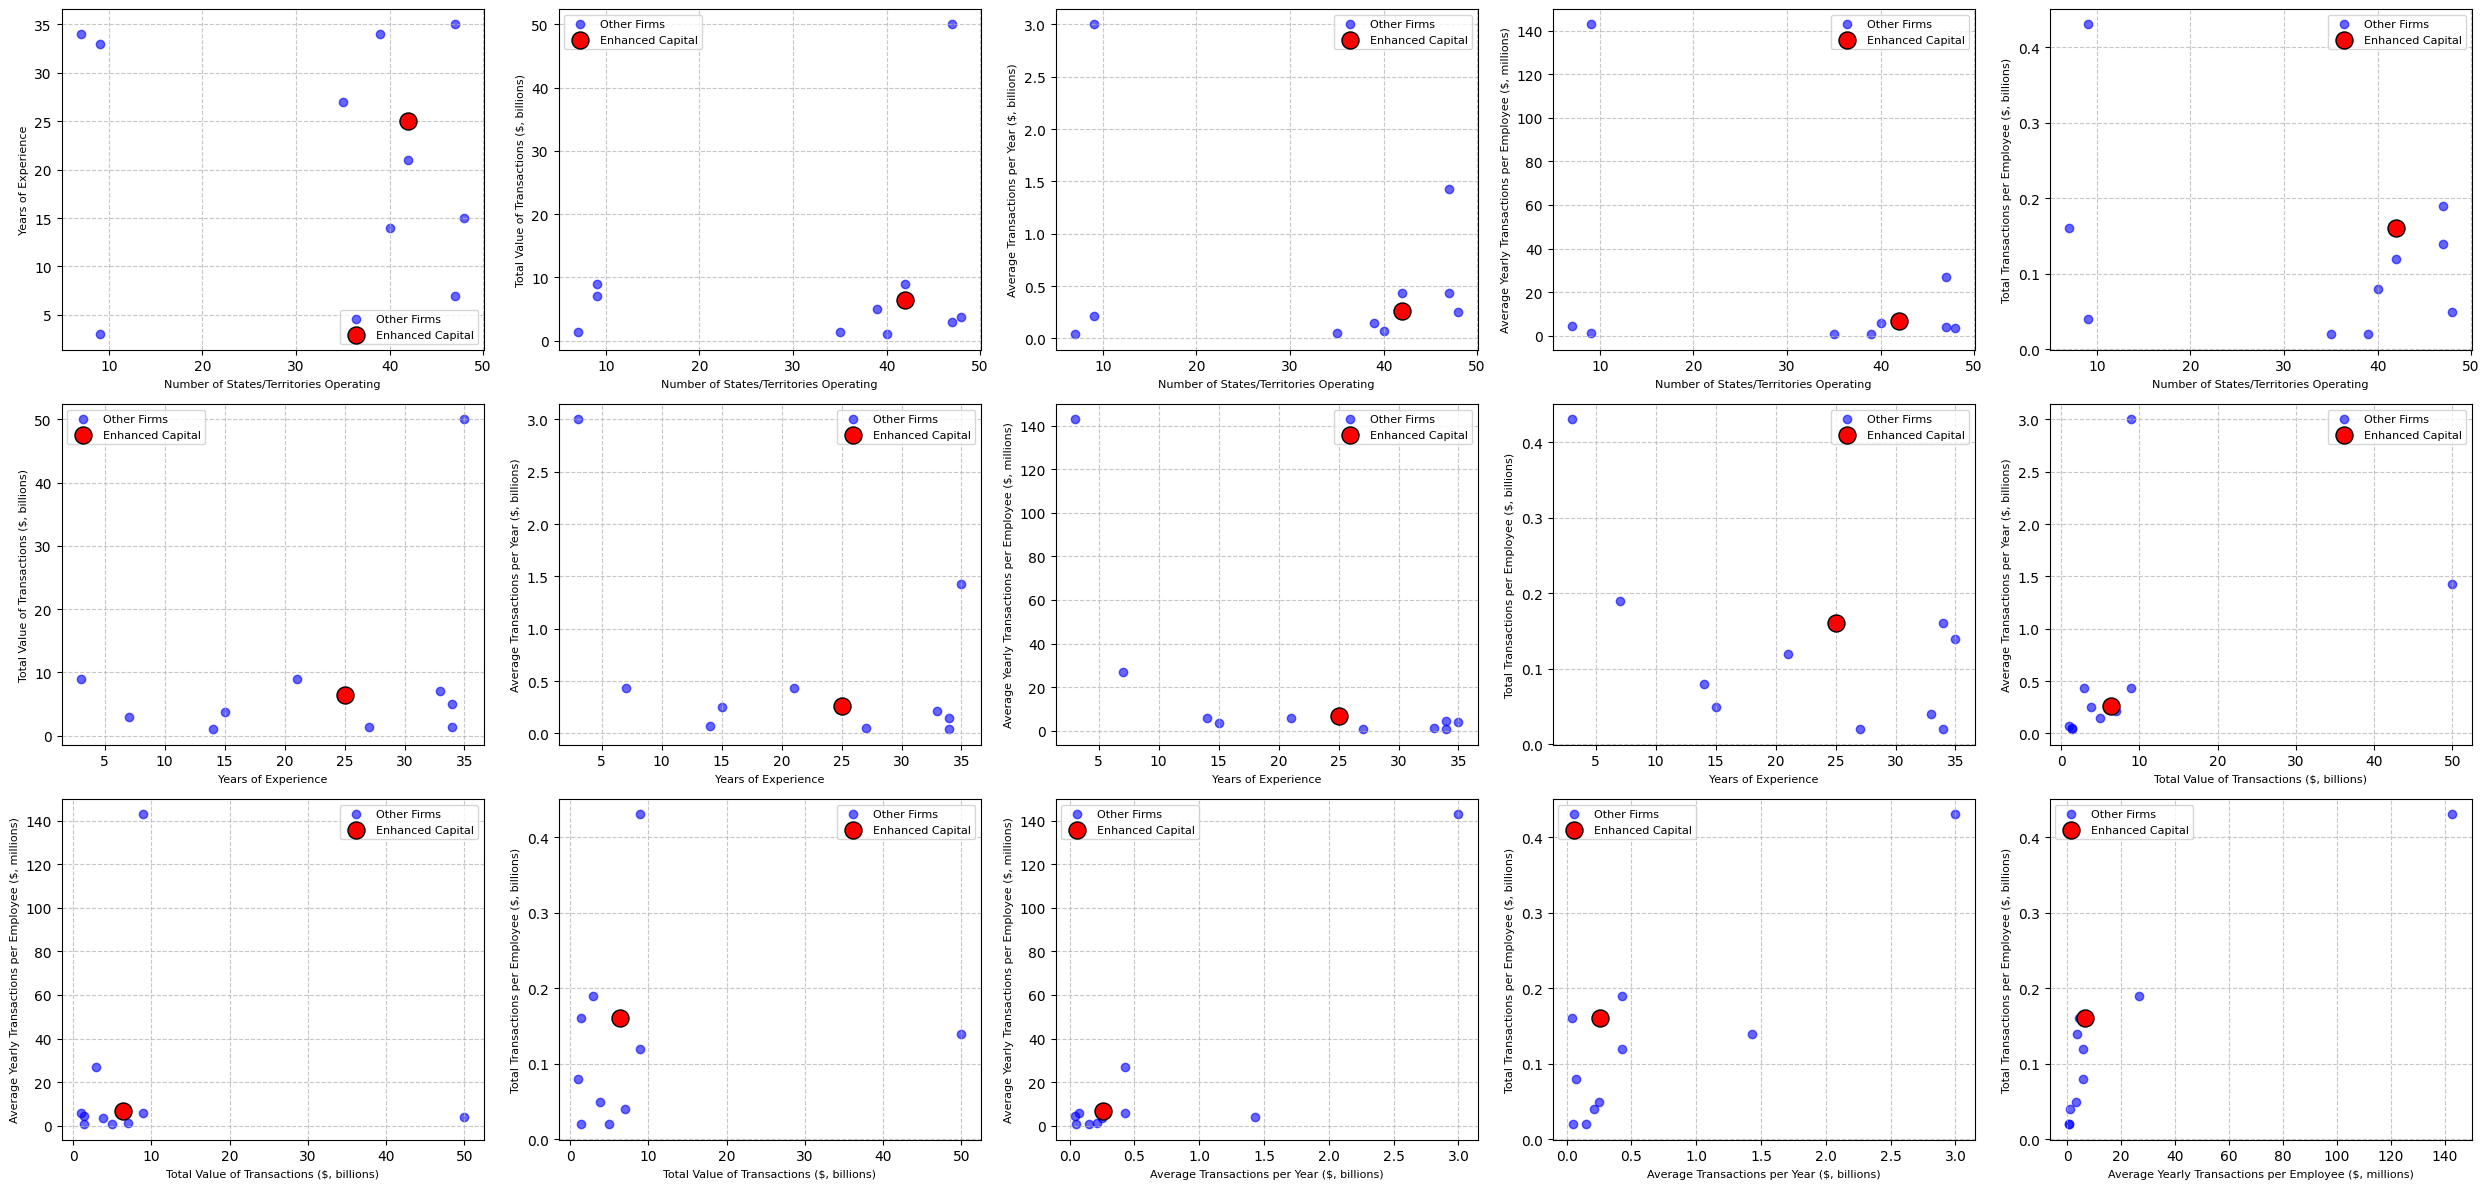

In [3]:
import itertools
import math

# Generate all unique pairs of metrics
metric_pairs = list(itertools.combinations(metrics_to_plot, 2))

print(f"Generating {len(metric_pairs)} plots...")

# Calculate grid dimensions for a more square-like layout (e.g., 3x5 for 15 plots)
num_plots = len(metric_pairs)
num_cols = 5 # Arbitrary choice for a good aspect ratio
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

for i, (x_metric, y_metric) in enumerate(metric_pairs):
    ax = axes[i]

    # Plot other firms
    ax.scatter(other_firms_data[x_metric], other_firms_data[y_metric], color='blue', label='Other Firms', alpha=0.6)

    # Highlight Enhanced Capital
    ax.scatter(enhanced_capital_data[x_metric], enhanced_capital_data[y_metric], color='red', s=150, label='Enhanced Capital', zorder=5, edgecolor='black', linewidth=1)

    #ax.set_title(f'{x_metric.replace(" ", "\n")} vs.\n{y_metric.replace(" ", "\n")}', fontsize=10) # Replace spaces with newlines for better title fit
    ax.set_xlabel(x_metric, fontsize=8)
    ax.set_ylabel(y_metric, fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.7)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Generating 15 plots...


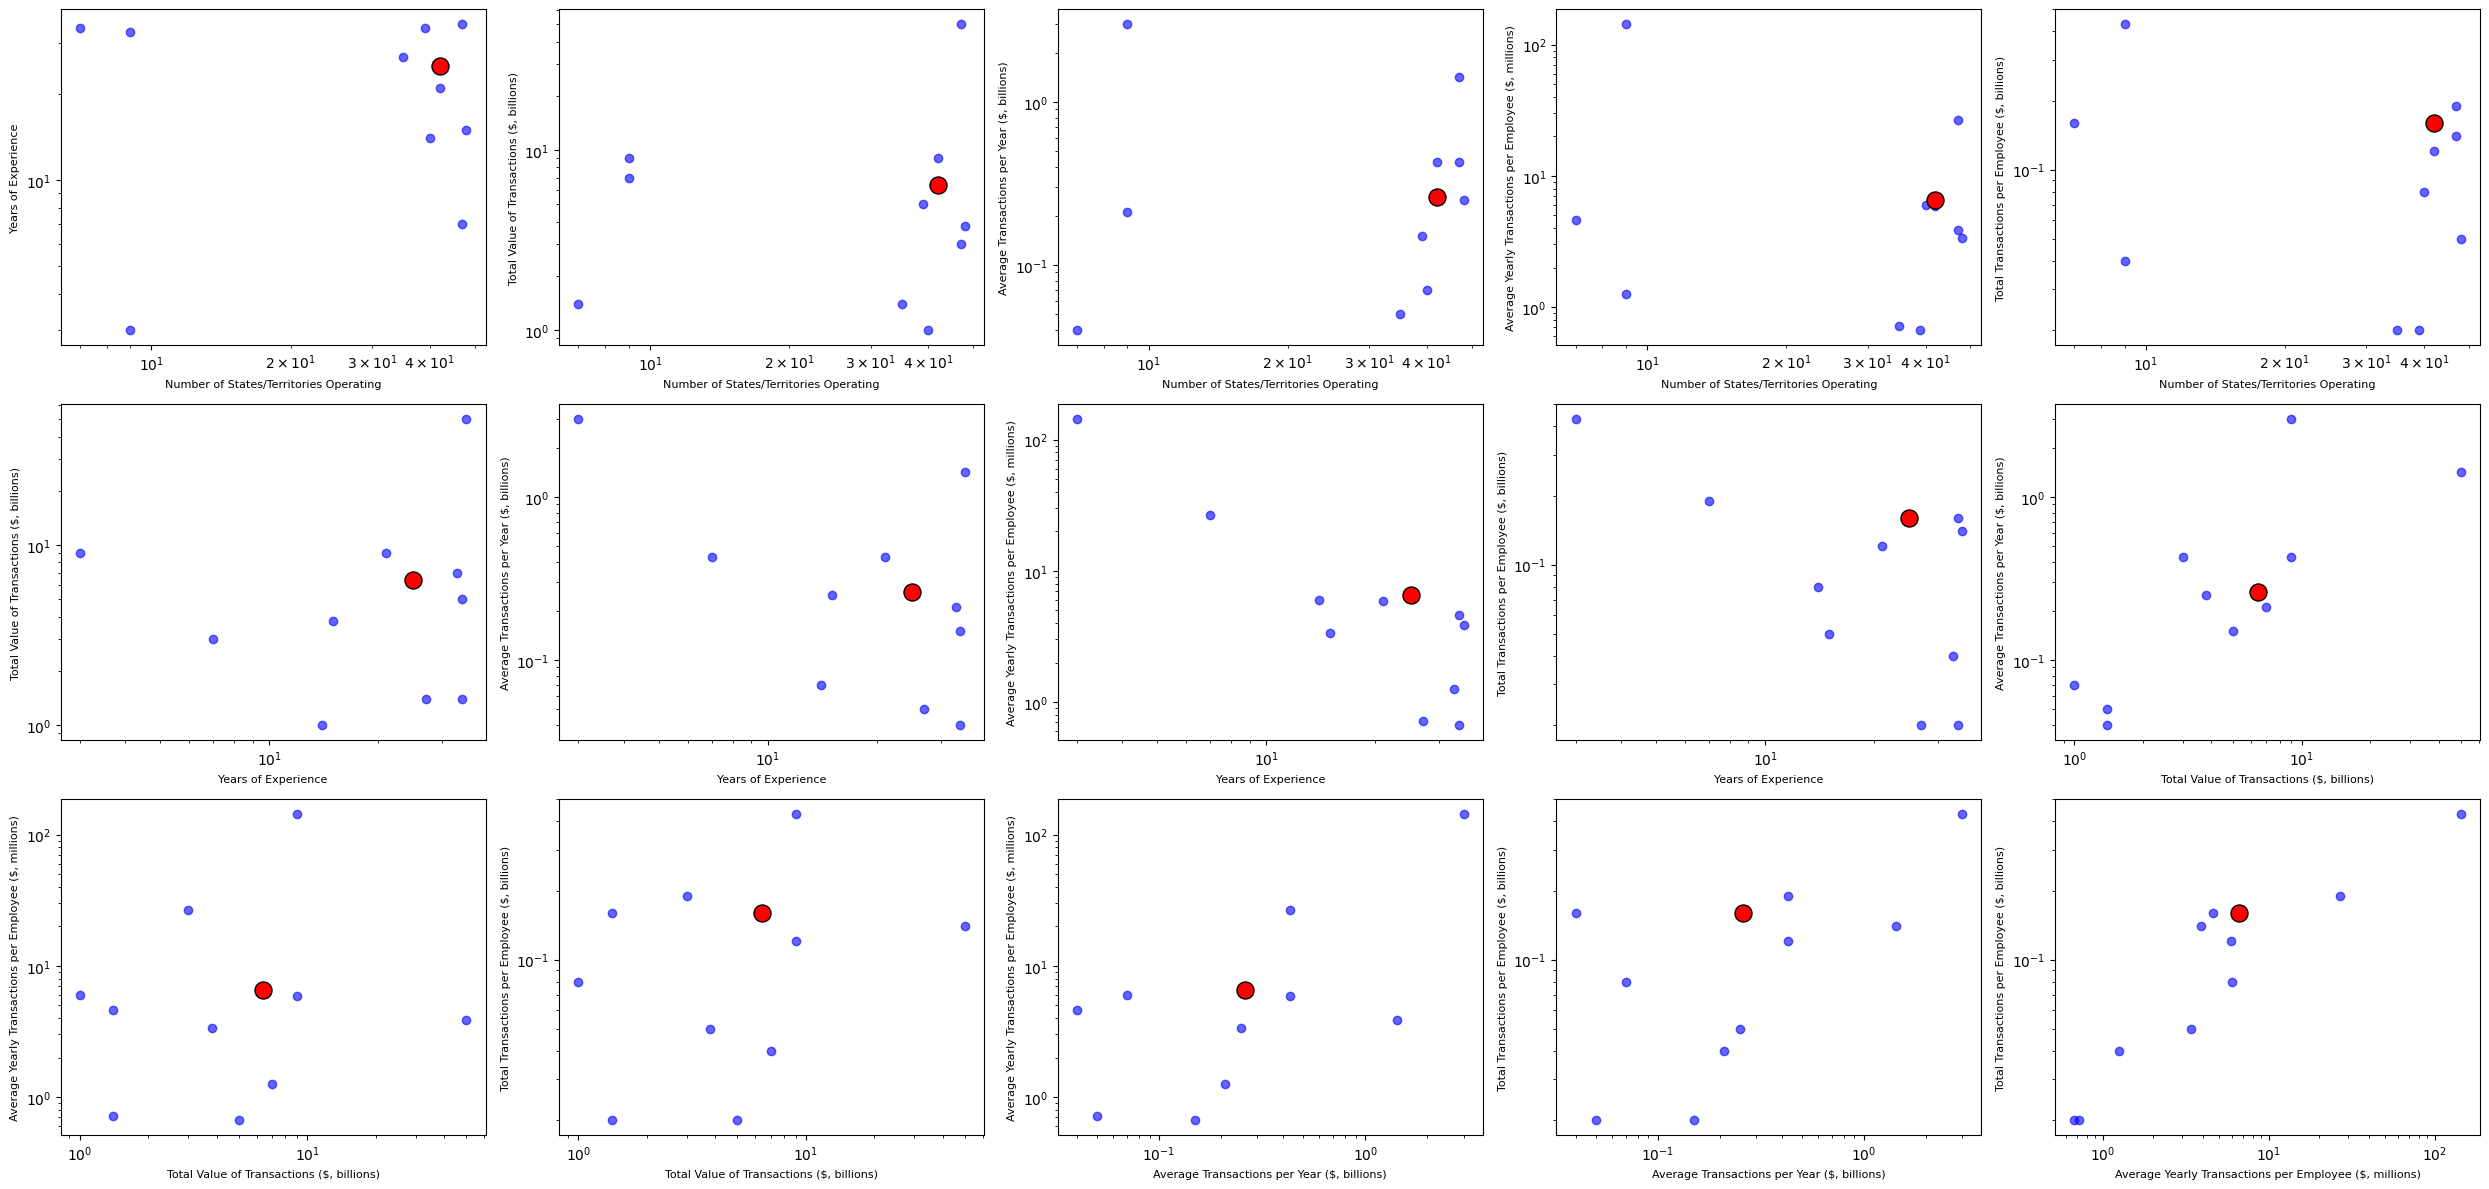

In [4]:
import itertools
import math

# Generate all unique pairs of metrics
metric_pairs = list(itertools.combinations(metrics_to_plot, 2))

print(f"Generating {len(metric_pairs)} plots...")

# Calculate grid dimensions for a more square-like layout (e.g., 3x5 for 15 plots)
num_plots = len(metric_pairs)
num_cols = 5 # Arbitrary choice for a good aspect ratio
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

for i, (x_metric, y_metric) in enumerate(metric_pairs):
    ax = axes[i]

    # Plot other firms
    ax.scatter(other_firms_data[x_metric], other_firms_data[y_metric], color='blue', label='Other Firms', alpha=0.6)

    # Highlight Enhanced Capital
    ax.scatter(enhanced_capital_data[x_metric], enhanced_capital_data[y_metric], color='red', s=150, label='Enhanced Capital', zorder=5, edgecolor='black', linewidth=1)

    #ax.set_title(f'{x_metric.replace(" ", "\n")} vs.\n{y_metric.replace(" ", "\n")}', fontsize=10) # Replace spaces with newlines for better title fit
    ax.set_xlabel(x_metric, fontsize=8)
    ax.set_ylabel(y_metric, fontsize=8)
    ax.set_xscale('log') # Set x-axis to log scale
    ax.set_yscale('log') # Set y-axis to log scale
    #ax.legend(fontsize=8)
    #ax.grid(True, linestyle='--', alpha=0.7)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

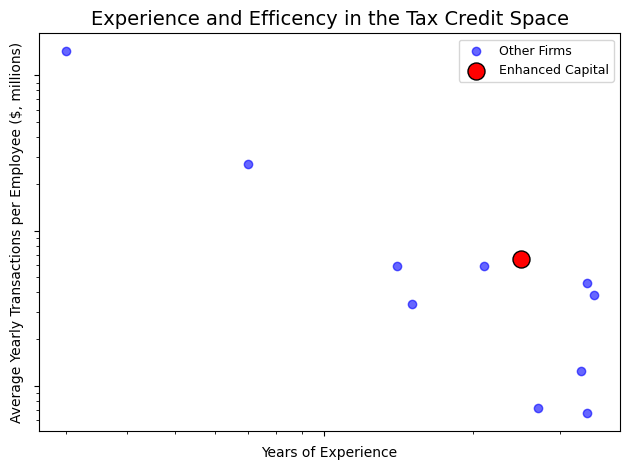

In [5]:
ax = plt.gca()
ax.scatter(other_firms_data['Years of Experience'], other_firms_data['Average Yearly Transactions per Employee ($, millions)'], color='blue', label='Other Firms', alpha=0.6)
ax.scatter(enhanced_capital_data['Years of Experience'], enhanced_capital_data['Average Yearly Transactions per Employee ($, millions)'], color='red', s=150, label='Enhanced Capital', zorder=5, edgecolor='black', linewidth=1)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Years of Experience', fontsize=10) # Increased fontsize for formal document
ax.set_ylabel('Average Yearly Transactions per Employee ($, millions)', fontsize=10) # Increased fontsize
ax.set_title("Experience and Efficency in the Tax Credit Space", fontsize=14) # Added title
ax.legend(fontsize=9)
ax.set_xticklabels([]) # Remove X numerical labels
ax.set_yticklabels([]) # Remove Y numerical labels
ax.minorticks_on() # Ensure minor ticks are on
plt.tight_layout() # Adjust layout for better fit
plt.show()

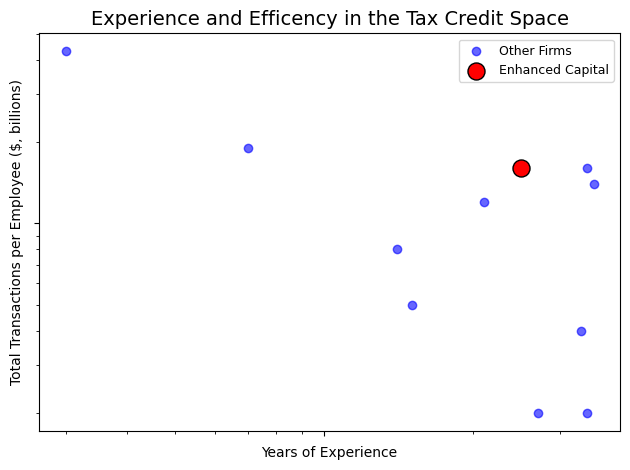

In [6]:
ax = plt.gca()
ax.scatter(other_firms_data['Years of Experience'], other_firms_data['Total Transactions per Employee ($, billions)'], color='blue', label='Other Firms', alpha=0.6)
ax.scatter(enhanced_capital_data['Years of Experience'], enhanced_capital_data['Total Transactions per Employee ($, billions)'], color='red', s=150, label='Enhanced Capital', zorder=5, edgecolor='black', linewidth=1)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Years of Experience', fontsize=10) # Increased fontsize for formal document
ax.set_ylabel('Total Transactions per Employee ($, billions)', fontsize=10) # Increased fontsize
ax.set_title("Experience and Efficency in the Tax Credit Space", fontsize=14) # Added title
ax.legend(fontsize=9)
ax.set_xticklabels([]) # Remove X numerical labels
ax.set_yticklabels([]) # Remove Y numerical labels
ax.minorticks_on() # Ensure minor ticks are on
plt.tight_layout() # Adjust layout for better fit
plt.show()

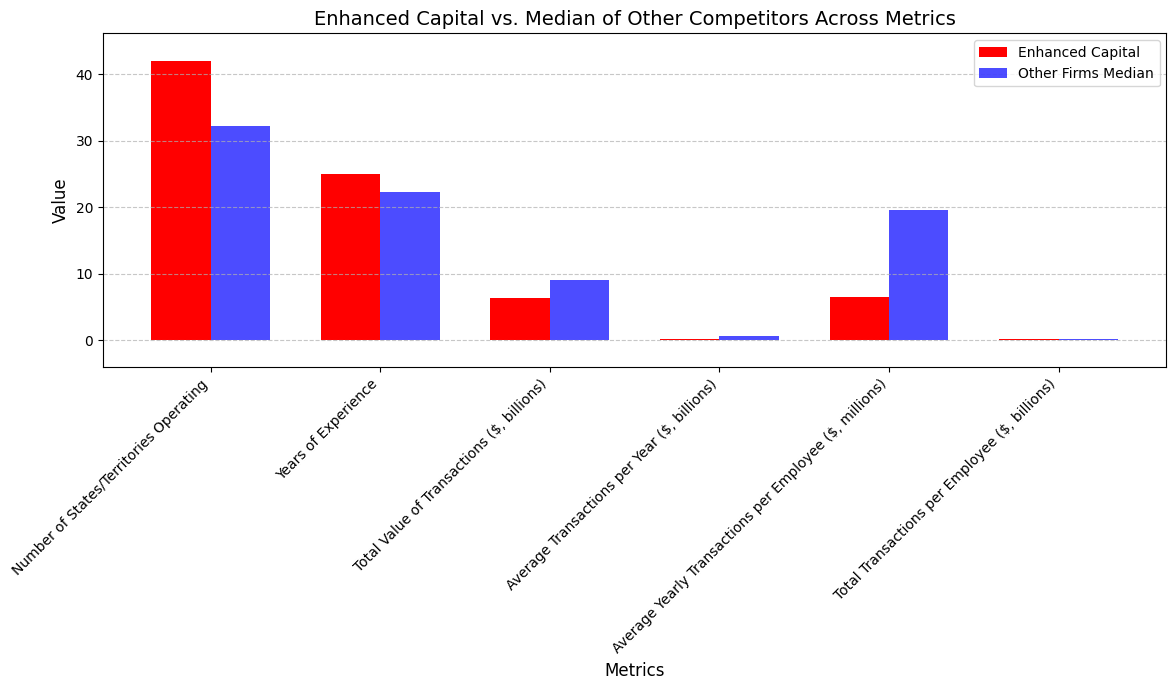

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate median for other firms for each metric
other_firms_median = other_firms_data[metrics_to_plot].mean()

# Get Enhanced Capital's values for the same metrics
enhanced_capital_values = enhanced_capital_data[metrics_to_plot]

# Prepare data for plotting
plot_data = pd.DataFrame({
    'Enhanced Capital': enhanced_capital_values,
    'Other Firms Median': other_firms_median
})

# Create the bar chart
fig, ax = plt.subplots(figsize=(12, 7))

# Define bar width and positions
bar_width = 0.35
index = np.arange(len(metrics_to_plot))

bar1 = ax.bar(index - bar_width/2, plot_data['Enhanced Capital'], bar_width, label='Enhanced Capital', color='red')
bar2 = ax.bar(index + bar_width/2, plot_data['Other Firms Median'], bar_width, label='Other Firms Median', color='blue', alpha=0.7)

# Add labels, title, and legend
ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Enhanced Capital vs. Median of Other Competitors Across Metrics', fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(metrics_to_plot, rotation=45, ha='right', fontsize=10) # Rotate labels for better readability
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Calculate dynamic y-axis limits for better visualization
min_val = min(plot_data['Enhanced Capital'].min(), plot_data['Other Firms Median'].min())
max_val = max(plot_data['Enhanced Capital'].max(), plot_data['Other Firms Median'].max())

# Add some padding to the y-axis limits
padding = (max_val - min_val) * 0.1
ax.set_ylim(min_val - padding, max_val + padding)

plt.tight_layout()
plt.show()

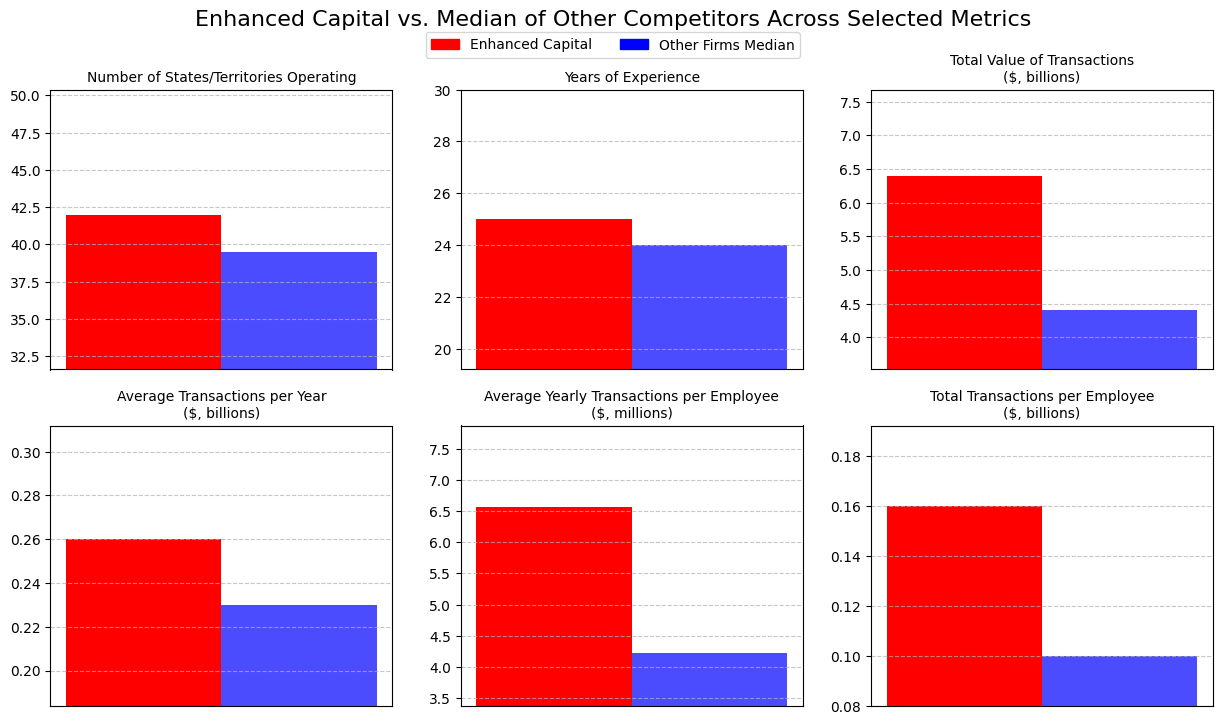

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Ensure pandas is imported

# Calculate median for other firms for each metric
other_firms_median = other_firms_data[metrics_to_plot].median()

# Get Enhanced Capital's values for the same metrics
enhanced_capital_values = enhanced_capital_data[metrics_to_plot]

# Prepare data for plotting
plot_data = pd.DataFrame({
    'Enhanced Capital': enhanced_capital_values,
    'Other Firms Median': other_firms_median
})

# Determine the number of subplots needed
num_metrics = len(metrics_to_plot)
num_cols = 3 # Adjust for desired layout
num_rows = (num_metrics + num_cols - 1) // num_cols # Calculate rows needed

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten() # Flatten for easy iteration over subplots

fig.suptitle('Enhanced Capital vs. Median of Other Competitors Across Selected Metrics', fontsize=16)

# Prepare legend handles and labels for the figure-level legend
legend_labels = ['Enhanced Capital', 'Other Firms Median']
legend_colors = ['red', 'blue']
legend_handles = [plt.Rectangle((0,0),1,1, color=c) for c in legend_colors]

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]

    ec_value = plot_data.loc[metric, 'Enhanced Capital']
    median_value = plot_data.loc[metric, 'Other Firms Median']

    bar_width = 0.05 # Made bars thinner

    # Plot bars closer together at a single x-position (e.g., 0)
    ax.bar(-bar_width/2, ec_value, bar_width, color='red') # Removed label here
    ax.bar(bar_width/2, median_value, bar_width, color='blue', alpha=0.7) # Removed label here

    ax.set_title(metric.replace(' ($,', '\n($,'), fontsize=10) # Split long titles for readability
    ax.set_xticks([]) # Remove x-ticks
    # ax.set_xticklabels() # No need for x-tick labels if ticks are removed

    # Removed value labels on top of bars as requested

    # Dynamic y-axis limits for each subplot, always starting from 0
    max_val_metric = max(ec_value, median_value)
    min_val_metric = min(ec_value, median_value)
    ax.set_ylim(min_val_metric * 0.8, max_val_metric * 1.2)

    # Add y-axis label to all subplots for clarity

    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add figure-level legend below the suptitle
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=2, fontsize=10)
plt.show()